# EXP031: Cumulative reward comparison — DQN vs MFI vs oracle MFI

`EXP031/results` に保存された `summary_*.csv` の `CumReward` 列（各stepまでの累積Fisher情報量の受検者平均）を比較プロットします。

- MFI: `summary_uncor_{bank_id}_MFI_MLE_python.csv`
- Oracle MFI: `summary_uncor_{bank_id}_MFI_oracle_MLE_python.csv`
- DQN: `summary_uncor_{bank_id}_DQN_MLE_gamma_*.csv`（見つかったすべてのgammaを対象）

累積報酬は割引なし（∑ FI(item, true_theta)）で、DQN、MFI、oracle MFIで同一定義を使用しています。


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP031").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


ROOT = find_project_root()
EXP031_RESULTS = ROOT / "EXP031" / "results"

BANK_ID = 1
BANK_TYPE = "uncor"
TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]

print(f"Project root : {ROOT}")
print(f"Results dir  : {EXP031_RESULTS}")

Project root : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir  : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results


In [2]:
REQUIRED_COLUMNS = {"step", "CumReward"}


def read_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required summary CSV not found: {path}")
    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    frame = frame.copy()
    rounded_steps = frame["step"].round().astype(int)
    if not np.allclose(frame["step"], rounded_steps):
        raise ValueError(f"{path.name} contains non-integer step values.")
    frame["step"] = rounded_steps
    if frame["step"].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate step values.")
    if set(frame["step"]) != set(range(1, TEST_LENGTH + 1)):
        raise ValueError(
            f"{path.name} must contain exactly steps 1 through {TEST_LENGTH}."
        )
    if not np.isfinite(frame["CumReward"]).all():
        raise ValueError(f"{path.name} contains non-finite CumReward values.")
    return frame.sort_values("step").reset_index(drop=True)


def gamma_sort_key(gamma: str) -> tuple[int, float | str]:
    try:
        return (0, float(gamma))
    except ValueError:
        return (1, gamma)


mfi_path = EXP031_RESULTS / f"summary_{BANK_TYPE}_{BANK_ID}_MFI_MLE_python.csv"
oracle_mfi_path = (
    EXP031_RESULTS / f"summary_{BANK_TYPE}_{BANK_ID}_MFI_oracle_MLE_python.csv"
)
mfi_summary = read_summary(mfi_path)
oracle_mfi_summary = read_summary(oracle_mfi_path)

if not mfi_summary["step"].equals(oracle_mfi_summary["step"]):
    raise ValueError("MFI and oracle MFI summaries have different steps.")

dqn_pattern = re.compile(
    rf"summary_{BANK_TYPE}_{BANK_ID}_DQN_MLE_gamma_(?P<gamma>.+)\.csv"
)
dqn_runs: dict[str, pd.DataFrame] = {}
dqn_paths: dict[str, Path] = {}
for path in sorted(
    EXP031_RESULTS.glob(f"summary_{BANK_TYPE}_{BANK_ID}_DQN_MLE_gamma_*.csv")
):
    match = dqn_pattern.fullmatch(path.name)
    if match is None:
        continue
    gamma = match.group("gamma")
    if gamma in dqn_runs:
        raise ValueError(f"Duplicate DQN summary for gamma={gamma}: {path}")
    dqn_runs[gamma] = read_summary(path)
    dqn_paths[gamma] = path

if not dqn_runs:
    raise FileNotFoundError(
        f"No DQN summary CSVs matched summary_{BANK_TYPE}_{BANK_ID}_DQN_MLE_gamma_*.csv"
    )

sorted_gammas = sorted(dqn_runs, key=gamma_sort_key)

print(f"MFI       : {mfi_path.name}")
print(f"Oracle MFI: {oracle_mfi_path.name}")
for gamma in sorted_gammas:
    final_cum = dqn_runs[gamma]["CumReward"].iloc[-1]
    print(
        f"DQN gamma={gamma}: {dqn_paths[gamma].name} (final CumReward={final_cum:.3f})"
    )
print(f"MFI final CumReward       : {mfi_summary['CumReward'].iloc[-1]:.3f}")
print(f"Oracle MFI final CumReward: {oracle_mfi_summary['CumReward'].iloc[-1]:.3f}")

MFI       : summary_uncor_1_MFI_MLE_python.csv
Oracle MFI: summary_uncor_1_MFI_oracle_MLE_python.csv
DQN gamma=0: summary_uncor_1_DQN_MLE_gamma_0.csv (final CumReward=10.921)
DQN gamma=0.1: summary_uncor_1_DQN_MLE_gamma_0.1.csv (final CumReward=10.902)
DQN gamma=0.3: summary_uncor_1_DQN_MLE_gamma_0.3.csv (final CumReward=10.579)
DQN gamma=0.6: summary_uncor_1_DQN_MLE_gamma_0.6.csv (final CumReward=10.290)
DQN gamma=0.9: summary_uncor_1_DQN_MLE_gamma_0.9.csv (final CumReward=8.680)
MFI final CumReward       : 12.093
Oracle MFI final CumReward: 13.076


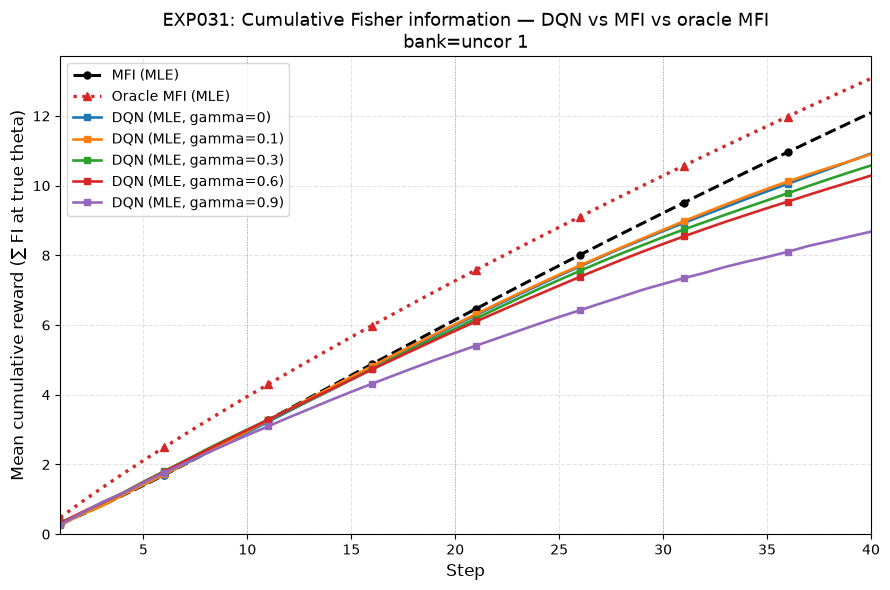

Saved figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/cum_reward_comparison_uncor_1.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    mfi_summary["step"],
    mfi_summary["CumReward"],
    color="black",
    linestyle="--",
    marker="o",
    markevery=5,
    markersize=5,
    linewidth=2.2,
    label="MFI (MLE)",
)
ax.plot(
    oracle_mfi_summary["step"],
    oracle_mfi_summary["CumReward"],
    color="tab:red",
    linestyle=":",
    marker="^",
    markevery=5,
    markersize=6,
    linewidth=2.4,
    label="Oracle MFI (MLE)",
)

cmap = plt.get_cmap("tab10")
for index, gamma in enumerate(sorted_gammas):
    curve = dqn_runs[gamma]
    ax.plot(
        curve["step"],
        curve["CumReward"],
        color=cmap(index % 10),
        marker="s",
        markevery=5,
        markersize=4,
        linewidth=1.9,
        label=f"DQN (MLE, gamma={gamma})",
    )

for step in KEY_STEPS:
    ax.axvline(step, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)

ax.set_title(
    f"EXP031: Cumulative Fisher information — DQN vs MFI vs oracle MFI\n"
    f"bank={BANK_TYPE} {BANK_ID}",
    fontsize=13,
)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Mean cumulative reward (∑ FI at true theta)", fontsize=12)
ax.set_xlim(1, TEST_LENGTH)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()

EXP031_RESULTS.mkdir(parents=True, exist_ok=True)
output_path = EXP031_RESULTS / f"cum_reward_comparison_{BANK_TYPE}_{BANK_ID}.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {output_path}")

In [4]:
def cum_reward_at(frame: pd.DataFrame, step: int) -> float:
    return float(frame.loc[frame["step"] == step, "CumReward"].iloc[0])


rows = [
    {
        "series": "MFI (MLE)",
        **{f"step_{step}": cum_reward_at(mfi_summary, step) for step in KEY_STEPS},
    },
    {
        "series": "Oracle MFI (MLE)",
        **{
            f"step_{step}": cum_reward_at(oracle_mfi_summary, step)
            for step in KEY_STEPS
        },
    },
]
for gamma in sorted_gammas:
    rows.append(
        {
            "series": f"DQN (MLE, gamma={gamma})",
            **{
                f"step_{step}": cum_reward_at(dqn_runs[gamma], step)
                for step in KEY_STEPS
            },
        }
    )

table = pd.DataFrame(rows).set_index("series")
print(table.to_string(float_format="{:.3f}".format))

table_path = EXP031_RESULTS / f"cum_reward_key_steps_{BANK_TYPE}_{BANK_ID}.csv"
table.to_csv(table_path)
print(f"Saved key-step CumReward table to: {table_path}")

                      step_10  step_20  step_30  step_40
series                                                  
MFI (MLE)               2.954    6.152    9.215   12.093
Oracle MFI (MLE)        3.950    7.271   10.286   13.076
DQN (MLE, gamma=0)      2.921    5.992    8.696   10.921
DQN (MLE, gamma=0.1)    2.954    6.025    8.732   10.902
DQN (MLE, gamma=0.3)    3.003    5.895    8.520   10.579
DQN (MLE, gamma=0.6)    2.990    5.835    8.327   10.290
DQN (MLE, gamma=0.9)    2.842    5.200    7.179    8.680
Saved key-step CumReward table to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/cum_reward_key_steps_uncor_1.csv
